# Task 3 EDA: Large Liquidation Reaction

This notebook covers the first part of the task:

- choose a definition of `large liquidation` using several notional thresholds;
- build reaction curves for Binance trades after a liquidation;
- compare trades in the same direction and in the opposite direction;
- visually estimate where the peak is and when the reaction fades.

By default, the notebook uses `binance_liquidations`, because this is the most direct and causally clean option for this EDA. If you want to inspect the same picture for `bybit`, just change `LIQ_SOURCE` to `"bybit"`.

In [ ]:
from __future__ import annotations

from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from tqdm.auto import tqdm

from src.config import BaselineConfig, source_path
from src.baseline_utils import add_bbo_mid, add_liq_notional, compute_markouts, load_window, to_us

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

cfg = BaselineConfig()

SPLIT = "train"
LIQ_SOURCE = "binance"
PERCENTILES = (0.90, 0.95, 0.99)
MARKOUT_HORIZON_S = 30
MAX_WINDOW_S = 300

assert SPLIT == "train", "For the first EDA step we usually inspect the train split"
assert LIQ_SOURCE in {"binance", "bybit"}

day_list = list(cfg.iter_days(split=SPLIT))
day_list[:3], len(day_list)


([datetime.datetime(2025, 12, 1, 0, 0, tzinfo=datetime.timezone.utc),
  datetime.datetime(2025, 12, 2, 0, 0, tzinfo=datetime.timezone.utc),
  datetime.datetime(2025, 12, 3, 0, 0, tzinfo=datetime.timezone.utc)],
 62)

In [2]:
def liq_source_name(liq_source: str) -> str:
    return "liq_binance" if liq_source == "binance" else "liq_bybit"


def liq_timestamp_shift_us(liq_source: str) -> int:
    return 0 if liq_source == "binance" else cfg.bybit_delay_us


def load_liq_slice(symbol: str, start_dt, end_dt, liq_source: str) -> pl.DataFrame:
    return add_liq_notional(
        load_window(
            source_path(cfg, liq_source_name(liq_source), symbol),
            start_us=to_us(start_dt),
            end_us=to_us(end_dt),
            columns=["timestamp", "side", "price", "amount"],
            timestamp_shift_us=liq_timestamp_shift_us(liq_source),
        )
    )


def load_trade_day(symbol: str, day_start, max_window_s: int) -> tuple[pl.DataFrame, np.ndarray]:
    day_end = day_start + timedelta(days=1)
    day_end_with_horizon = day_end + timedelta(seconds=max_window_s)

    trades_df = load_window(
        source_path(cfg, "trades", symbol),
        start_us=to_us(day_start),
        end_us=to_us(day_end_with_horizon),
        columns=["timestamp", "side", "price", "amount"],
    )
    if trades_df.is_empty():
        return trades_df, np.array([], dtype=np.float64)

    bbo_df = add_bbo_mid(
        load_window(
            source_path(cfg, "bbo", symbol),
            start_us=to_us(day_start - timedelta(days=1)),
            end_us=to_us(day_end_with_horizon),
            columns=["timestamp", "bid_price", "ask_price", "bid_amount", "ask_amount"],
        )
    )
    if bbo_df.is_empty():
        return trades_df, np.full(len(trades_df), np.nan)

    markouts = compute_markouts(trades_df, bbo_df, horizons_s=(MARKOUT_HORIZON_S,))
    mid_future = markouts[f"mid_future_{MARKOUT_HORIZON_S}s"]
    taker_sign = markouts["maker_sign"]
    trade_price = trades_df["price"].to_numpy()

    trade_markout_bps = np.full(len(trades_df), np.nan)
    valid = np.isfinite(mid_future)
    trade_markout_bps[valid] = (
        taker_sign[valid] * (mid_future[valid] - trade_price[valid]) / trade_price[valid] * 10_000.0
    )
    return trades_df, trade_markout_bps


def compute_threshold_candidates(liq_source: str, percentiles: tuple[float, ...]) -> dict[str, float]:
    notionals = []
    split_start = day_list[0]
    split_end = day_list[-1] + timedelta(days=1)

    for symbol in cfg.symbols:
        liq_df = load_liq_slice(symbol, split_start, split_end, liq_source)
        if not liq_df.is_empty():
            notionals.append(liq_df["notional"].to_numpy())

    all_notional = np.concatenate(notionals)
    return {f"p{int(p * 100)}": float(np.quantile(all_notional, p)) for p in percentiles}


def accumulate_reaction_curve(threshold: float, liq_source: str) -> pl.DataFrame:
    same_sum = np.zeros(MAX_WINDOW_S, dtype=np.float64)
    same_n = np.zeros(MAX_WINDOW_S, dtype=np.int64)
    opp_sum = np.zeros(MAX_WINDOW_S, dtype=np.float64)
    opp_n = np.zeros(MAX_WINDOW_S, dtype=np.int64)
    liq_count = 0

    for day_start in tqdm(day_list, desc=f"curve >= {threshold:,.0f}"):
        day_end = day_start + timedelta(days=1)
        day_end_with_window = day_end + timedelta(seconds=MAX_WINDOW_S)

        for symbol in cfg.symbols:
            trades_df, trade_markout_bps = load_trade_day(symbol, day_start, MAX_WINDOW_S)
            if trades_df.is_empty():
                continue

            liq_df = load_liq_slice(symbol, day_start, day_end, liq_source)
            if liq_df.is_empty():
                continue

            large_liq_df = liq_df.filter(pl.col("notional") >= threshold)
            if large_liq_df.is_empty():
                continue

            trade_ts = trades_df["timestamp"].to_numpy()
            trade_side = trades_df["side"].to_numpy()
            valid_markout = np.isfinite(trade_markout_bps)

            liq_ts = large_liq_df["timestamp"].to_numpy()
            liq_side = large_liq_df["side"].to_numpy()

            for event_ts, event_side in zip(liq_ts, liq_side, strict=False):
                liq_count += 1
                left = np.searchsorted(trade_ts, event_ts, side="left")
                right = np.searchsorted(trade_ts, event_ts + MAX_WINDOW_S * 1_000_000, side="left")
                if left >= right:
                    continue

                rel_sec = ((trade_ts[left:right] - event_ts) // 1_000_000).astype(np.int64)
                local_valid = valid_markout[left:right] & (rel_sec >= 0) & (rel_sec < MAX_WINDOW_S)
                if not local_valid.any():
                    continue

                local_bins = rel_sec[local_valid]
                local_markout = trade_markout_bps[left:right][local_valid]
                local_side = trade_side[left:right][local_valid]

                same_mask = local_side == event_side
                if same_mask.any():
                    same_bins = local_bins[same_mask]
                    same_vals = local_markout[same_mask]
                    bucket_sum = np.bincount(same_bins, weights=same_vals, minlength=MAX_WINDOW_S)
                    bucket_n = np.bincount(same_bins, minlength=MAX_WINDOW_S)
                    hit = bucket_n > 0
                    same_sum[hit] += bucket_sum[hit] / bucket_n[hit]
                    same_n[hit] += 1

                opp_mask = local_side != event_side
                if opp_mask.any():
                    opp_bins = local_bins[opp_mask]
                    opp_vals = local_markout[opp_mask]
                    bucket_sum = np.bincount(opp_bins, weights=opp_vals, minlength=MAX_WINDOW_S)
                    bucket_n = np.bincount(opp_bins, minlength=MAX_WINDOW_S)
                    hit = bucket_n > 0
                    opp_sum[hit] += bucket_sum[hit] / bucket_n[hit]
                    opp_n[hit] += 1

    same_curve = np.full(MAX_WINDOW_S, np.nan)
    opp_curve = np.full(MAX_WINDOW_S, np.nan)
    same_hit = same_n > 0
    opp_hit = opp_n > 0
    same_curve[same_hit] = same_sum[same_hit] / same_n[same_hit]
    opp_curve[opp_hit] = opp_sum[opp_hit] / opp_n[opp_hit]

    return pl.DataFrame(
        {
            "seconds_after_liq": np.arange(MAX_WINDOW_S, dtype=np.int64),
            "same_direction_markout_bps": same_curve,
            "opposite_direction_markout_bps": opp_curve,
            "same_direction_liq_count": same_n,
            "opposite_direction_liq_count": opp_n,
            "large_liq_count": np.full(MAX_WINDOW_S, liq_count, dtype=np.int64),
        }
    )


def summarize_curve(curve_df: pl.DataFrame, column: str) -> dict[str, float | int]:
    values = curve_df[column].to_numpy()
    valid_idx = np.flatnonzero(np.isfinite(values))
    if len(valid_idx) == 0:
        return {"peak_second": -1, "peak_value_bps": np.nan, "fade_below_0_1bps_second": -1}

    peak_pos = valid_idx[np.nanargmax(np.abs(values[valid_idx]))]
    fade_candidates = valid_idx[np.abs(values[valid_idx]) < 0.1]
    fade_second = int(fade_candidates[0]) if len(fade_candidates) else -1
    return {
        "peak_second": int(peak_pos),
        "peak_value_bps": float(values[peak_pos]),
        "fade_below_0_1bps_second": fade_second,
    }


## 1. Candidate thresholds for `large liquidation`

First we compute notional thresholds on the train split. This gives natural candidates for the `large liquidation` definition.

In [3]:
thresholds = compute_threshold_candidates(LIQ_SOURCE, PERCENTILES)
thresholds_df = pl.DataFrame(
    {
        "threshold_name": list(thresholds.keys()),
        "notional_usd": list(thresholds.values()),
    }
).with_columns(pl.col("notional_usd").round(2))
thresholds_df


threshold_name,notional_usd
str,f64
"""p90""",14986.51
"""p95""",34801.32
"""p99""",162945.22


## 2. Reaction curves after a large liquidation

For each event, we take all Binance trades in the window `[t_liq, t_liq + 300s)`, compute their `30s` markout, and build two curves:

- same direction: the trade side matches the liquidation side;
- opposite direction: the trade side is opposite to the liquidation side.

Aggregation is done in two steps:

1. first, the average markout inside each liquidation and second bucket;
2. then, the average of those values across all large liquidations.

This prevents one liquidation from getting extra weight just because more trades happened nearby.

In [4]:
curves = {}
curve_summaries = []

for threshold_name, threshold_value in thresholds.items():
    curve_df = accumulate_reaction_curve(threshold_value, LIQ_SOURCE)
    curves[threshold_name] = curve_df

    same_summary = summarize_curve(curve_df, "same_direction_markout_bps")
    opp_summary = summarize_curve(curve_df, "opposite_direction_markout_bps")
    curve_summaries.append(
        {
            "threshold_name": threshold_name,
            "threshold_usd": round(threshold_value, 2),
            "same_peak_second": same_summary["peak_second"],
            "same_peak_value_bps": round(same_summary["peak_value_bps"], 4),
            "same_fade_below_0_1bps_second": same_summary["fade_below_0_1bps_second"],
            "opp_peak_second": opp_summary["peak_second"],
            "opp_peak_value_bps": round(opp_summary["peak_value_bps"], 4),
            "opp_fade_below_0_1bps_second": opp_summary["fade_below_0_1bps_second"],
        }
    )

curve_summary_df = pl.DataFrame(curve_summaries)
curve_summary_df


curve >= 14,987:   0%|          | 0/62 [00:00<?, ?it/s]

curve >= 34,801:   0%|          | 0/62 [00:00<?, ?it/s]

curve >= 162,945:   0%|          | 0/62 [00:00<?, ?it/s]

threshold_name,threshold_usd,same_peak_second,same_peak_value_bps,same_fade_below_0_1bps_second,opp_peak_second,opp_peak_value_bps,opp_fade_below_0_1bps_second
str,f64,i64,f64,i64,i64,f64,i64
"""p90""",14986.51,0,-0.4249,52,270,-0.3078,44
"""p95""",34801.32,0,-0.5038,69,8,0.3567,19
"""p99""",162945.22,23,-1.0981,72,24,0.9868,72


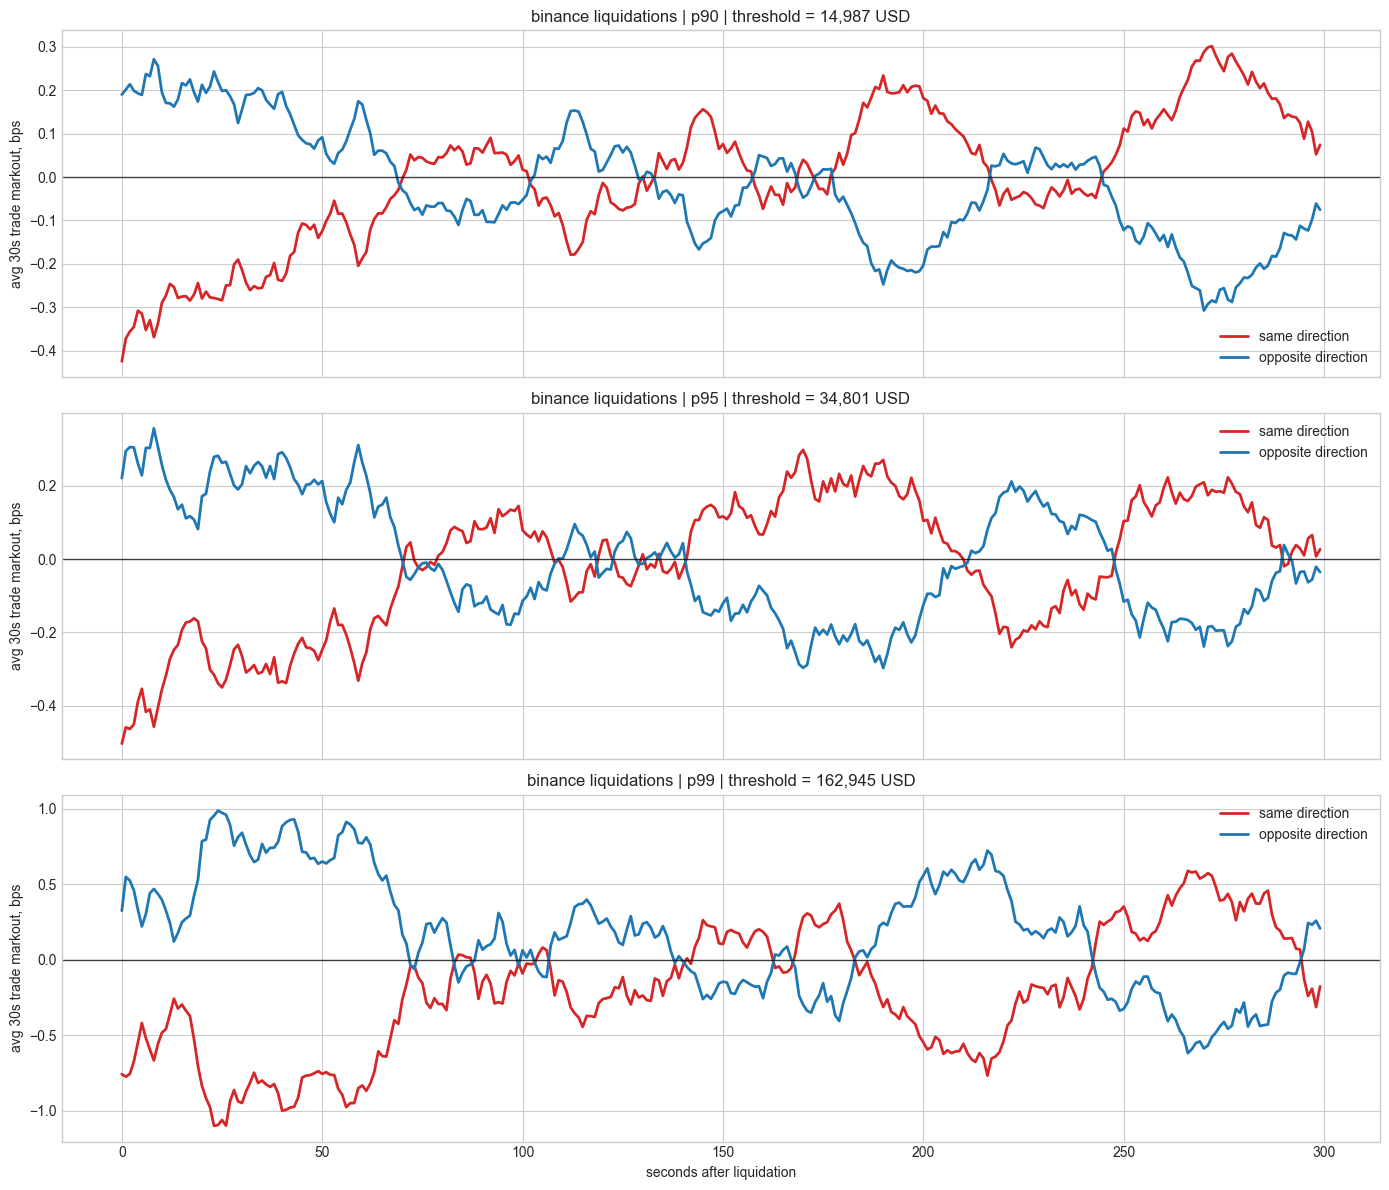

In [5]:
fig, axes = plt.subplots(len(curves), 1, figsize=(14, 4 * len(curves)), sharex=True)
if len(curves) == 1:
    axes = [axes]

for ax, (threshold_name, curve_df) in zip(axes, curves.items(), strict=False):
    x = curve_df["seconds_after_liq"].to_numpy()
    same_y = curve_df["same_direction_markout_bps"].to_numpy()
    opp_y = curve_df["opposite_direction_markout_bps"].to_numpy()

    ax.plot(x, same_y, label="same direction", linewidth=2.0, color="#d62728")
    ax.plot(x, opp_y, label="opposite direction", linewidth=2.0, color="#1f77b4")
    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.7)
    ax.set_title(f"{LIQ_SOURCE} liquidations | {threshold_name} | threshold = {thresholds[threshold_name]:,.0f} USD")
    ax.set_ylabel("avg 30s trade markout, bps")
    ax.legend()

axes[-1].set_xlabel("seconds after liquidation")
plt.tight_layout()
plt.show()
